## Preprocessing Pipeline Description
## -- Stage 1: Load .mat files and apply a 50:1 imbalance to the raw signals (before segmentation).
## -- Stage 2: Generate scalograms, segment signals into overlapping blocks (1600 samples, 320 interval) and one-hot encode labels for 10 classes.
## -- Stage 3: Perform an 80:20 class-wise time-based train-test split.

## Set Up Environment 

In [12]:
import tensorflow as tf
import numpy as np
import random
import pywt
from scipy.ndimage import zoom
import os
from skimage.transform import resize

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# --- Stage 1---
## Load CWRU Bearing Data 

In [13]:
def load_and_imbalance_cwru_data(folder_path, imbalance_ratio=50):
    """
    Load CWRU bearing data from .mat files and apply imbalance to raw signals.

    Args:
        folder_path (str): Path to the directory containing .mat files.
        imbalance_ratio (int): Ratio of normal to fault signal lengths (default: 50).

    Returns:
        pd.DataFrame: DataFrame with columns 'Condition', 'Fault Size (mm)', 'Fault Label', 'Signal'.
    """
    data_dict = {
        'Condition': [],
        'Fault Size (mm)': [],
        'Fault Label': [],
        'Signal': []
    }

    conditions = [
        ('99.mat', 'Normal', 0, 0),
        ('124.mat', 'RE (Rolling element)', 0.18, 1),
        ('111.mat', 'IR (Inner ring)', 0.18, 2),
        ('137.mat', 'OR (Outer ring)', 0.18, 3),
        ('191.mat', 'RE (Rolling element)', 0.36, 4),
        ('176.mat', 'IR (Inner ring)', 0.36, 5),
        ('203.mat', 'OR (Outer ring)', 0.36, 6),
        ('228.mat', 'RE (Rolling element)', 0.54, 7),
        ('215.mat', 'IR (Inner ring)', 0.54, 8),
        ('240.mat', 'OR (Outer ring)', 0.54, 9)
    ]

    # Load normal signal to determine target length
    normal_signal = None
    for file_name, condition, fault_size, fault_label in conditions:
        if fault_label == 0:  # Normal class
            file_path = os.path.join(folder_path, file_name)
            file_number = file_name.split(".")[0].zfill(3)
            normal_signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
            break

    normal_length = len(normal_signal)
    target_fault_length = max(1000, normal_length // imbalance_ratio)  # Ensure minimum length for segmentation

    for file_name, condition, fault_size, fault_label in conditions:
        file_path = os.path.join(folder_path, file_name)
        file_number = file_name.split(".")[0].zfill(3)
        signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
        
        # Apply imbalance by subsampling fault signals
        if fault_label != 0:  # Fault classes
            if len(signal) > target_fault_length:
                signal = signal[:target_fault_length]
        
        data_dict['Condition'].append(condition)
        data_dict['Fault Size (mm)'].append(fault_size)
        data_dict['Fault Label'].append(fault_label)
        data_dict['Signal'].append(signal)

    df = pd.DataFrame(data_dict)
    print("\nRaw Signal Lengths After Imbalance Preprocessing:")
    for class_idx, row in df.iterrows():
        print(f"Class {class_idx} (Fault Label: {row['Fault Label']}, {row['Condition']}): {len(row['Signal'])} data points")

    return df

## Imbalance introduction

In [14]:
def preprocess_train_for_imbalance(segments, labels, imbalance_ratio=50):
    """
    Apply imbalance preprocessing to sampled training segments to achieve specified ratio.

    Args:
        segments (List[np.ndarray]): List of sampled segment arrays (n_segments, samples_per_block).
        labels (List[int]): List of corresponding fault labels.
        imbalance_ratio (int): Ratio of normal to fault segments (default: 50).

    Returns:
        List[np.ndarray]: List of preprocessed training segment arrays.
    """
    processed_segments = []
    normal_segments = next((seg for seg, lbl in zip(segments, labels) if lbl == 0), np.array([]))
    n_normal_segments = normal_segments.shape[0]
    target_fault_segments = max(1, n_normal_segments // imbalance_ratio)

    for segment_array, fault_label in zip(segments, labels):
        n_segments = segment_array.shape[0]
        if n_segments == 0:
            print(f"No segments available for Fault Label {fault_label}. Skipping.")
            processed_segments.append(np.array([]).reshape(0, segment_array.shape[1]))
            continue
        target = n_normal_segments if fault_label == 0 else target_fault_segments
        selected_segments = segment_array[:min(target, n_segments)]
        processed_segments.append(selected_segments)
    return processed_segments

# --- Stage 2 ---
## Windowing with Overlap

In [15]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

## Scalogram generation

In [16]:
def generate_scalogram(segment, image_shape, fs=48000, scales=np.arange(1, 128), wavelet='morl'):
    coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
    scalogram = np.abs(coeffs)
    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
    scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
    return scalogram

## Reshape, one-hot encode data

In [17]:
def segment_and_generate_scalograms(df, image_shape, samples_per_block, interval_length, n_classes):
    segment_list = []
    one_hot_labels = []
    integer_labels = []

    for class_idx, row in df.iterrows():
        signal = row['Signal']
        fault_label = row['Fault Label']
        condition = row['Condition']

        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        scalograms = np.array([generate_scalogram(seg, image_shape, fs=48000) for seg in segments])
        # scalograms_resized = np.array([zoom(scal, (target_size[0]/scal.shape[0], target_size[1]/scal.shape[1]), order=1) for scal in scalograms])
        # scalograms_resized = np.expand_dims(scalograms_resized, axis=-1)  # Add channel dimension

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Segments: {n_segments} segments")
        print(f"Scalograms shape: {scalograms.shape}")

        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, class_idx] = 1
            labels = np.full((n_segments, 1), class_idx)

            segment_list.append(scalograms)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels)

    return segment_list, one_hot_labels, integer_labels

# --- Stage 3: --


## Time-Based Train-Test Split

In [18]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, df, train_ratio=0.8, n_classes=10):
    """
    Perform time-based class-wise train-test split.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): List of one-hot encoded label arrays.
        integer_labels (List[np.ndarray]): List of integer label arrays.
        df (pd.DataFrame): DataFrame with 'Signal', 'Fault Label', 'Condition'.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
            - X_ are 4D arrays for CNN (n_samples, 40, 40, 1).
            - Y_ are one-hot labels (n_samples, n_classes).
            - y_ are integer labels (n_samples, 1).
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    post_split_train_lengths = []
    post_split_test_lengths = []

    image_shape = (96, 96)

    fault_labels = df['Fault Label'].values
    conditions = df['Condition'].values

    for class_idx, (signal, segments, one_hot, integer, fault_label, condition) in enumerate(
        zip(df['Signal'], segment_list, one_hot_labels, integer_labels, fault_labels, conditions)
    ):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        post_split_train_lengths.append((class_idx, fault_label, condition, train_segments.shape[0]))
        post_split_test_lengths.append((class_idx, fault_label, condition, test_segments.shape[0]))

        if train_segments.shape[0] > 0:
            train_one_hot = one_hot[:train_size]
            train_labels = integer[:train_size]
            X_train_list.append(train_segments)
            Y_train_list.append(train_one_hot)
            y_train_list.append(train_labels)

        if test_segments.shape[0] > 0:
            test_one_hot = one_hot[train_size:]
            test_labels = integer[train_size:]
            X_test_list.append(test_segments)
            Y_test_list.append(test_one_hot)
            y_test_list.append(test_labels)

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Train segments (post-split): {train_segments.shape[0]} segments")
        print(f"Test segments (post-split): {test_segments.shape[0]} segments")
        # print(f"Sample train data (first 5 elements): {train_segments[0][:5] if train_segments.shape[0] > 0 else 'Empty'}")
        # print(f"Sample test data (first 5 elements): {test_segments[0][:5] if test_segments.shape[0] > 0 else 'Empty'}")

    print("\nTraining Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    print("\nTest Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_test_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape([-1, image_shape[0], image_shape[1], 1])
    X_2D_test = X_test.reshape([-1, image_shape[0], image_shape[1], 1])

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    # print(f"Sample X_train values (first 5 elements): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
    print(f"Final Y_train shape: {Y_train.shape}")
    # print(f"Sample Y_train values (first 5): {Y_train[:5] if Y_train.size > 0 else 'Empty'}")
    print(f"Final y_train shape: {y_train.shape}")
    # print(f"Sample y_train values (first 5): {y_train[:5] if y_train.size > 0 else 'Empty'}")
    print(f"\nFinal X_test shape: {X_2D_test.shape}")
    # print(f"Sample X_test values (first 5 elements): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
    print(f"Final Y_test shape: {Y_test.shape}")
    # print(f"Sample Y_test values (first 5): {Y_test[:5] if Y_test.size > 0 else 'Empty'}")
    print(f"Final y_test shape: {y_test.shape}")
    # print(f"Sample y_test values (first 5): {y_test[:5] if y_test.size > 0 else 'Empty'}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [19]:
# --- Execution ---
folder_path = './CWRU_BearingData_Load_2HP'
interval_length = 320
samples_per_block = 1600
n_classes = 10
train_ratio = 0.8
imbalance_ratio = 50

# Stage 1: Load and apply imbalance
df = load_and_imbalance_cwru_data(folder_path, imbalance_ratio)

# Stage 2: Segment signals and generate scalograms
segments, one_hot_labels, integer_labels = segment_and_generate_scalograms(df, image_shape=(96, 96), samples_per_block=1600, interval_length=320, n_classes=10)

# Stage 3: Train-test split
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = time_train_test_split(
    segments, one_hot_labels, integer_labels, df, train_ratio, n_classes
)



Raw Signal Lengths After Imbalance Preprocessing:
Class 0 (Fault Label: 0, Normal): 485063 data points
Class 1 (Fault Label: 1, RE (Rolling element)): 9701 data points
Class 2 (Fault Label: 2, IR (Inner ring)): 9701 data points
Class 3 (Fault Label: 3, OR (Outer ring)): 9701 data points
Class 4 (Fault Label: 4, RE (Rolling element)): 9701 data points
Class 5 (Fault Label: 5, IR (Inner ring)): 9701 data points
Class 6 (Fault Label: 6, OR (Outer ring)): 9701 data points
Class 7 (Fault Label: 7, RE (Rolling element)): 9701 data points
Class 8 (Fault Label: 8, IR (Inner ring)): 9701 data points
Class 9 (Fault Label: 9, OR (Outer ring)): 9701 data points

Class 0 (Fault Label: 0, Normal):
Segments: 1511 segments
Scalograms shape: (1511, 96, 96)

Class 1 (Fault Label: 1, RE (Rolling element)):
Segments: 26 segments
Scalograms shape: (26, 96, 96)

Class 2 (Fault Label: 2, IR (Inner ring)):
Segments: 26 segments
Scalograms shape: (26, 96, 96)

Class 3 (Fault Label: 3, OR (Outer ring)):
Segmen

## Model definition

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}") 
print(f"X_2D_test shape: {X_2D_test.shape}")  
print(f"Y_train shape: {Y_train.shape}") 
print(f"Y_test shape: {Y_test.shape}") 
print(f"Y_train shape: {y_label_train.shape}") 
print(f"Y_test shape: {y_label_test.shape}")  

class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), padding='same', input_shape=(96, 96, 1)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(32, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(64, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(128, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(100),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.5),
            layers.Dense(96),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(
            optimizer='adam',
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy']
        )
        return model

X_2D_train shape: (1388, 96, 96, 1)
X_2D_test shape: (357, 96, 96, 1)
Y_train shape: (1388, 10)
Y_test shape: (357, 10)
Y_train shape: (1388, 1)
Y_test shape: (357, 1)


In [21]:
import numpy as np
import pandas as pd

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# X_train distribution (using Y_train)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("Blocks per class in X_train:")
print(df_train_orig.to_string(index=False))

# Train set distribution (using Y_train, same as above since no additional split)
train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

# Test set distribution (using Y_test)
test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

# # y_train_split and y_test_split (same as Y_train and Y_test distributions)
# print("\ny_train_split distribution (assumed):")
# print(df_train.to_string(index=False))
# print("\ny_test_split distribution (assumed):")
# print(df_test.to_string(index=False))

Blocks per class in X_train:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     303
  RE 0.18       6
  IR 0.18       6
  OR 0.18       6
  RE 0.36       6
  IR 0.36       6
  OR 0.36       6
  RE 0.54       6
  IR 0.54       6
  OR 0.54       6


## Multiclass Classification CNN Model Training with Imbalanced Data


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# Training with k-fold validation
foldername = "CNN2D_results/Imbalanced-Ratio-Scalogram-BatchNorm/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 10))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 10))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-01 22:48:25.066803: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown a

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6881 - loss: 1.3144

2025-07-01 22:49:18.597025: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-07-01 22:49:18.597675: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_accuracy improved from -inf to 0.01439, saving model to CNN2D_results/Imbalanced-Ratio-Scalogram-BatchNorm/best_model_fold_1.h5


...

35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9925 - loss: 0.0475 - val_accuracy: 0.0866 - val_loss: 1.6566
Epoch 15/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9931 - loss: 0.0402
Epoch 15: val_accuracy improved from 0.08664 to 0.89892, saving model to CNN2D_results/Imbalanced-Ratio-Scalogram-BatchNorm/best_model_fold_4.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9931 - loss: 0.0405 - val_accuracy: 0.8989 - val_loss: 0.6030
Epoch 16/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9901 - loss: 0.0465
Epoch 16: val_accuracy did not improve from 0.89892
35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9900 - loss: 0.0466 - val_accuracy: 0.8881 - val_loss: 0.4434
Epoch 17/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9925 - loss: 0.0367
Epoch 17: val_accuracy improved from 0.89892 to 0.93141, saving model to CNN2D_results/Imbalanced-Ratio-Scalogram-BatchNorm/best_model_fold_4.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9926 - loss: 0.0368 - val_accuracy: 0.9314 - val_loss: 0.1827
Epoch 18/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9945 - loss: 0.0311
Epoch 18: val_accuracy improved from 0.93141 to 0.99639, saving model to CNN2D_results/Imbalanced-Ratio-Scalogram-BatchNorm/best_model_fold_4.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9944 - loss: 0.0313 - val_accuracy: 0.9964 - val_loss: 0.0369
Epoch 19/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9945 - loss: 0.0305
Epoch 19: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9944 - loss: 0.0306 - val_accuracy: 0.9928 - val_loss: 0.0759
Epoch 20/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9909 - loss: 0.0295
Epoch 20: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9910 - loss: 0.0296 - val_accuracy: 0.9856 - val_loss: 0.1247
Epoch 21/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9913 - loss: 0.0400
Epoch 21: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9912 - loss: 0.0402 - val_accuracy: 0.9856 - val_loss: 0.0377
Epoch 22/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9927 - loss: 0.0299
Epoch 22: val_accuracy did not improve from 

35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9937 - loss: 0.0230 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 30/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9995 - loss: 0.0107
Epoch 30: val_accuracy did not improve from 1.00000
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9995 - loss: 0.0108 - val_accuracy: 0.9928 - val_loss: 0.0224
Epoch 31/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9984 - loss: 0.0130
Epoch 31: val_accuracy did not improve from 1.00000
35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9984 - loss: 0.0131 - val_accuracy: 0.9964 - val_loss: 0.0094
Epoch 32/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9980 - loss: 0.0149
Epoch 32: val_accuracy did not improve from 1.00000
35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9980 - loss: 0.0149 - val_accuracy: 0.9964 - val_loss: 0.0148
Epoch 33/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9982 - loss: 0.0171
Epoch 33: val_accuracy did not improve from 

## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 99.98%
Test Accuracy: 97.82%
Train Precision: 99.98%
Test Precision: 98.41%
Train Recall: 99.98%
Test Recall: 97.82%
Train F1-score: 99.98%
Test F1-score: 97.82%
Train Log Loss: 0.0138
Test Log Loss: 0.0646
Train Balanced Accuracy: 99.88%
Test Balanced Accuracy: 87.00%


2025-07-02 22:12:55.786923: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-07-02 22:12:55.788183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 466ms/step


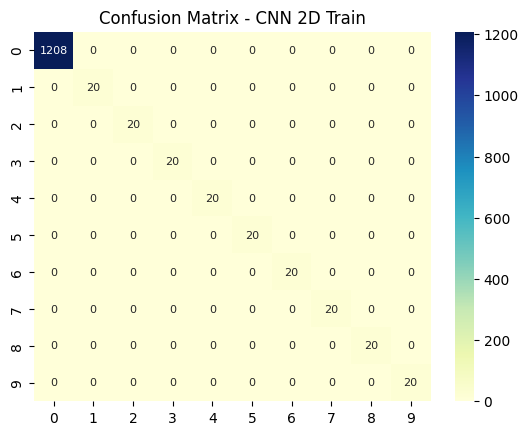

2025-07-02 22:13:16.919590: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-07-02 22:13:16.920482: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step


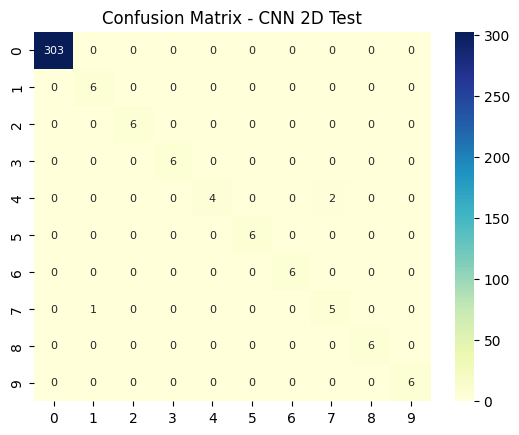

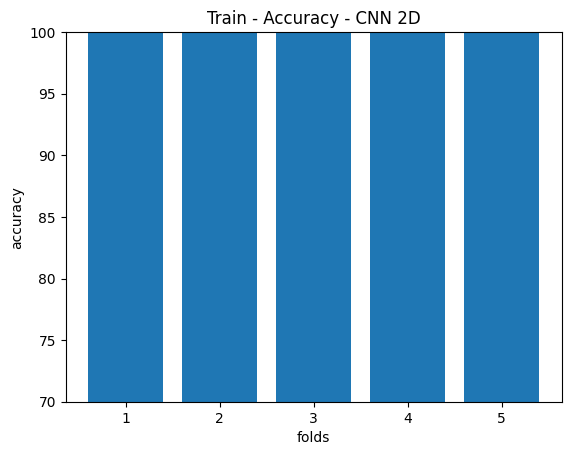

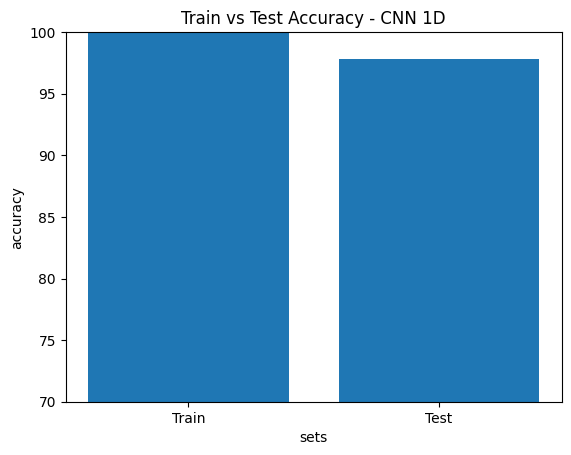

In [23]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_2D_train_precision = np.mean(precision_1D) * 100
CNN_2D_test_precision = np.mean(precision_1D_test) * 100
CNN_2D_train_recall = np.mean(recall_1D) * 100
CNN_2D_test_recall = np.mean(recall_1D_test) * 100
CNN_2D_train_f1 = np.mean(f1_1D) * 100
CNN_2D_test_f1 = np.mean(f1_1D_test) * 100
CNN_2D_train_log_loss = np.mean(log_loss_1D)
CNN_2D_test_log_loss = np.mean(log_loss_1D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_2D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_2D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()

In [24]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,100.00000,96.638655,100.000000,97.893412,100.00000,96.638655,100.000000,96.264051,0.024216,0.095582,100.000,80.000000
1,2,100.00000,97.198880,100.000000,98.179272,100.00000,97.198880,100.000000,96.958784,0.016715,0.073760,100.000,83.333333
2,3,99.90991,98.319328,99.915209,98.439376,99.90991,98.319328,99.909822,98.306399,0.007772,0.054789,99.375,90.000000
3,4,100.00000,97.759104,100.000000,98.259340,100.00000,97.759104,100.000000,97.729168,0.001417,0.050040,100.000,86.666667
4,5,100.00000,99.159664,100.000000,99.279712,100.00000,99.159664,100.000000,99.146736,0.019101,0.048944,100.000,95.000000


In [ ]:
## turn into excel
metrics_df.to_excel(os.path.join(foldername, "Imbalanced_CNN2D_Metrics.xlsx"), index=False)